# Week 11 - Introduction to Modeling, part 2

# 1. Lesson - No lesson this week

# 2. Weekly graph question

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.metrics import root_mean_squared_error, make_scorer, mean_absolute_error, mean_squared_error, accuracy_score, r2_score, classification_report, confusion_matrix,ConfusionMatrixDisplay,f1_score, precision_score, recall_score,roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold, cross_val_score, KFold, cross_validate
import seaborn as sns
import matplotlib.pyplot as plt

The book names one of Vonnegut's rules as "keep it simple" and another as "have the guts to cut."  Here is some data from the previous week's lesson.  If you had to cut one of the two plots below, which would it be?  Which seems more interesting or important?  Explain.  (Should "amount of training data used" or "number of estimators" be on the x-axis.)

In [2]:
np.random.seed(0)
num_points = 10000
feature_1a = np.random.random(size = num_points) * 3
feature_2a = np.random.random(size = num_points) * 3
feature_3a = np.random.random(size = num_points) * 3
train_target = (feature_1a - 2 * feature_2a) * feature_3a + np.random.normal(size = num_points)
feature_1b = np.random.random(size = num_points) * 3
feature_2b = np.random.random(size = num_points) * 3
feature_3b = np.random.random(size = num_points) * 3
test_target = (feature_1b - 2 * feature_2b) * feature_3b + np.random.normal(size = num_points)
train_df = pd.DataFrame({"f1": feature_1a, "f2": feature_2a, "f3": feature_3a})
test_df = pd.DataFrame({"f1": feature_1b, "f2": feature_2b, "f3": feature_3b})
rf = RandomForestRegressor()
rf.fit(train_df.values, train_target)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [3]:
rmse_lst = list()
rf = RandomForestRegressor()
for x in range(round(num_points / 20), num_points, round(num_points / 20)):
    rf.fit(train_df.values[0:x,:], train_target[0:x])
    rmse_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

import matplotlib.pyplot as plt

Text(0, 0.5, 'Loss function')

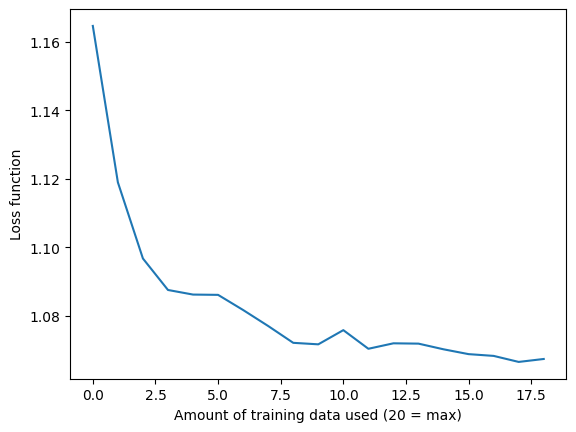

In [4]:
plt.plot(rmse_lst)
plt.xlabel("Amount of training data used (20 = max)")
plt.ylabel("Loss function")

In [5]:
num_trees_lst = list()
for n_estimators in range(1, 100, 3):
    rf = RandomForestRegressor(n_estimators = n_estimators)
    rf.fit(train_df.values, train_target)
    num_trees_lst.append(root_mean_squared_error(rf.predict(test_df.values), test_target))

Text(0, 0.5, 'Loss function')

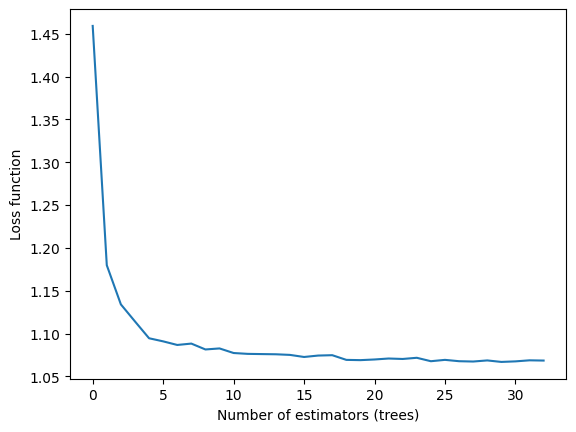

In [6]:
plt.plot(num_trees_lst)
plt.xlabel("Number of estimators (trees)")
plt.ylabel("Loss function")

If I had to cut one plot, I would cut the plot about the number of estimators. That plot is useful, but the main message is simple: after a small number of trees, the loss does not improve very much.

I would keep the plot about the amount of training data used. This plot seems more interesting and important because it shows how model performance changes as we give the model more training data. The loss decreases as more training data is used, but the improvement becomes smaller later. This is a useful learning-curve pattern.

For the x-axis, the graph should use the amount of training data used if the goal is to show how performance changes with more data. If the goal is hyperparameter tuning, then the number of estimators should be on the x-axis. In this case, I would choose the amount of training data used because it gives the more important story.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:

* Implement a random forest model.
* Perform cross-validation.
* Tune hyperparameters.
* Evaluate a performance metric.

If you like, you can try other types of models, too (beyond linear regression and random forest) although you will have many opportunities to do that next semester.

### **Dataset 1: E-commerce User Behavior**

This section continues the modeling analysis for Dataset 1. The dataset is treated as an interaction-level dataset because each row represents an order or customer-product interaction, not one unique customer.   
The target variable for this analysis is Add to Cart, which represents purchase intent.

#### **1.1 Load and Check**

The cleaned EDA dataset is loaded as the starting point for modeling. Missing values were already handled during preprocessing by removing a very small number of rows with missing or invalid values.   
The dataset is checked again before building the Random Forest model.

In [7]:
# Load the cleaned EDA version of Dataset 1

df_behavior = pd.read_pickle("data/df_behavior_eda.pkl")

df_behavior.shape

(51207, 27)

In [8]:
# Quick check of the dataset

df_behavior.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51207 entries, 0 to 51288
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Customer ID          51207 non-null  object        
 1   Customer Name        51207 non-null  object        
 2   Segment              51207 non-null  object        
 3   City                 51207 non-null  object        
 4   State                51207 non-null  object        
 5   Country              51207 non-null  object        
 6   Region               51207 non-null  object        
 7   Gender               51207 non-null  object        
 8   Age                  51207 non-null  int64         
 9   Education            51207 non-null  object        
 10  Marital Status       51207 non-null  object        
 11  Order ID             51207 non-null  object        
 12  Order Date           51207 non-null  datetime64[ns]
 13  Months               51207 non-null 

In [9]:
# Check missing values

df_behavior.isna().sum().sort_values(ascending=False)

Customer ID            0
Customer Name          0
Segment                0
City                   0
State                  0
Country                0
Region                 0
Gender                 0
Age                    0
Education              0
Marital Status         0
Order ID               0
Order Date             0
Months                 0
Ship Mode              0
Product Category       0
Product                0
Sales                  0
Quantity               0
Discount               0
Profit                 0
Shipping Cost          0
Order Priority         0
Browsing Time (min)    0
Like                   0
Share                  0
Add to Cart            0
dtype: int64

The cleaned EDA dataset has 51,207 rows and 27 columns. There are no missing values in the dataset at this stage. The dataset includes numeric, categorical, binary, and date variables.

#### **1.2 Target Selection and Class Balance**

In [10]:
# Check class balance for the target variable

target_behavior = "Add to Cart"
df_behavior[target_behavior].value_counts(normalize=True).round(3)

Add to Cart
1    0.667
0    0.333
Name: proportion, dtype: float64

The target variable is moderately imbalanced. Add to Cart = 1 makes up about 66.7% of the data, while Add to Cart = 0 makes up about 33.3%.   
This imbalance is not extreme, so oversampling is not applied. However, a stratified train/test split will be used to keep the same class balance in both the training and test sets.   
Accuracy will be reported, but precision, recall, F1-score, and the confusion matrix will also be reviewed because accuracy alone may be misleading.

#### **1.3 Feature Selection, One-Hot Encoding, and Train/Test Split**

In [11]:
# Check unique values in categorical/object columns

object_cols_behavior = df_behavior.select_dtypes(include="object").columns

unique_counts_behavior = pd.DataFrame({
    "column": object_cols_behavior,
    "unique_count": [df_behavior[col].nunique() for col in object_cols_behavior]
}).sort_values("unique_count", ascending=False)

unique_counts_behavior

,column,unique_count
10,Order ID,51191
0,Customer ID,794
1,Customer Name,794
3,City,547
4,State,319
5,Country,84
14,Product,42
6,Region,13
11,Months,12
8,Education,5


Add to Cart is used as the target variable. The model predicts add-to-cart behavior at the interaction level.

Identifier columns are not used as features because they may cause the model to memorize records. The raw Order Date column is also removed, but Months is kept as a simpler time-based feature.

City, State, and Country are left out to keep the first model simpler. Region is used as the main location feature. Sales, Quantity, Discount, Profit, Shipping Cost, Ship Mode, and Order Priority are also left out because they may contain order-stage information and could create data leakage.

The final feature set includes customer profile, product context, time context, and engagement variables. Categorical variables are converted with one-hot encoding before modeling.

In [12]:
# Define the target variable
target_behavior = "Add to Cart"
y_behavior = df_behavior[target_behavior].copy()

# Columns not used in Model 
target_and_id_cols_behavior = ["Add to Cart","Customer ID","Customer Name","Order ID"]
date_cols_removed_behavior = ["Order Date"]
high_cardinality_location_cols_behavior = ["City","State","Country"]
possible_leakage_cols_behavior = ["Sales","Quantity","Discount","Profit","Shipping Cost","Ship Mode","Order Priority"]
removed_cols_behavior = (target_and_id_cols_behavior+ date_cols_removed_behavior+ high_cardinality_location_cols_behavior+ possible_leakage_cols_behavior)

# Create feature set by dropping removed columns
X_behavior = df_behavior.drop(columns=removed_cols_behavior).copy()
X_behavior.columns

Index(['Segment', 'Region', 'Gender', 'Age', 'Education', 'Marital Status',
       'Months', 'Product Category', 'Product', 'Browsing Time (min)', 'Like',
       'Share'],
      dtype='object')

In [13]:
# One-hot encode categorical variables
X_behavior_encoded = pd.get_dummies(X_behavior,drop_first=True,dtype=int)

# Split the data into training and test sets
X_train_behavior, X_test_behavior, y_train_behavior, y_test_behavior = train_test_split(X_behavior_encoded,y_behavior,test_size=0.2,random_state=42,stratify=y_behavior)

print("shapes of training and test sets:")
print(X_train_behavior.shape, X_test_behavior.shape, y_train_behavior.shape, y_test_behavior.shape)
print()

# Check class balance in training and test sets
print("Training target balance:")
print(y_train_behavior.value_counts(normalize=True).round(3))

print("\nTest target balance:")
print(y_test_behavior.value_counts(normalize=True).round(3))


shapes of training and test sets:
(40965, 79) (10242, 79) (40965,) (10242,)

Training target balance:
Add to Cart
1    0.667
0    0.333
Name: proportion, dtype: float64

Test target balance:
Add to Cart
1    0.667
0    0.333
Name: proportion, dtype: float64


#### **1.4 Baseline Random Forest Model**

In [14]:
# Build and train the baseline Random Forest model
rf_baseline_behavior = RandomForestClassifier(random_state=42)
rf_baseline_behavior.fit(X_train_behavior, y_train_behavior)

# Make predictions on the test set
y_pred_baseline_behavior = rf_baseline_behavior.predict(X_test_behavior)

# Evaluate the baseline model
baseline_accuracy_behavior = accuracy_score(y_test_behavior,y_pred_baseline_behavior)

print("Baseline Random Forest Accuracy:", round(baseline_accuracy_behavior, 3))
print("\nClassification Report:")
print(classification_report(y_test_behavior, y_pred_baseline_behavior))

Baseline Random Forest Accuracy: 0.69

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.52      0.53      3411
           1       0.76      0.78      0.77      6831

    accuracy                           0.69     10242
   macro avg       0.65      0.65      0.65     10242
weighted avg       0.69      0.69      0.69     10242



Baseline Confusion Matrix:
[[1771 1640]
 [1536 5295]]


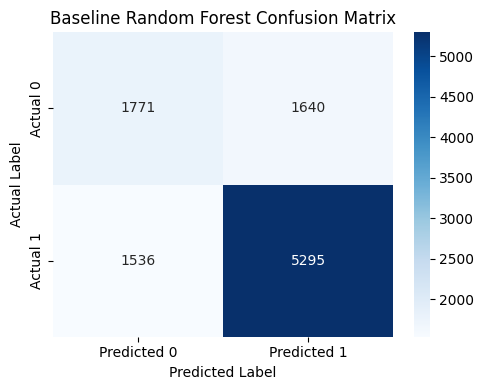

In [15]:
# Confusion matrix for the baseline model
baseline_cm_behavior = confusion_matrix(y_test_behavior,y_pred_baseline_behavior)
print(f"Baseline Confusion Matrix:\n{baseline_cm_behavior}")

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(baseline_cm_behavior,annot=True,fmt="d",cmap="Blues", xticklabels=["Predicted 0", "Predicted 1"],yticklabels=["Actual 0", "Actual 1"])

plt.title("Baseline Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

The baseline Random Forest model reached an accuracy of about 0.69.   
The model performed better for Add to Cart = 1 than for Add to Cart = 0. This is expected because class 1 is the larger class. Accuracy alone is not enough, so precision, recall, and F1-score are also reviewed.

#### **1.5 Cross-Validation**

Cross-validation is used to check whether the baseline model performs consistently across different parts of the training data. The test set is not used during cross-validation, so it can stay as a final holdout set.

In [16]:
# Set up stratified cross-validation
cv_behavior = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

# Cross-validation using accuracy
cv_accuracy_scores_behavior = cross_val_score(rf_baseline_behavior,X_train_behavior,y_train_behavior,cv=cv_behavior,scoring="accuracy")
cv_accuracy_scores_behavior

array([0.68863664, 0.68961308, 0.68851459, 0.6854632 , 0.69522763])

In [17]:
# Accuracy cross-validation summary
print("CV Accuracy Scores:", cv_accuracy_scores_behavior.round(3))
print("Mean CV Accuracy:", round(cv_accuracy_scores_behavior.mean(), 3))
print("CV Accuracy Std:", round(cv_accuracy_scores_behavior.std(), 3))

CV Accuracy Scores: [0.689 0.69  0.689 0.685 0.695]
Mean CV Accuracy: 0.689
CV Accuracy Std: 0.003


In [18]:
# Cross-validation using macro F1-score
cv_f1_scores_behavior = cross_val_score(rf_baseline_behavior,X_train_behavior,y_train_behavior,cv=cv_behavior,scoring="f1_macro")
cv_f1_scores_behavior

array([0.64445951, 0.64823403, 0.64735644, 0.64591892, 0.65360578])

In [19]:
# F1 cross-validation summary
print("CV Macro F1 Scores:", cv_f1_scores_behavior.round(3))
print("Mean CV Macro F1:", round(cv_f1_scores_behavior.mean(), 3))
print("CV Macro F1 Std:", round(cv_f1_scores_behavior.std(), 3))

CV Macro F1 Scores: [0.644 0.648 0.647 0.646 0.654]
Mean CV Macro F1: 0.648
CV Macro F1 Std: 0.003


The cross-validation results are close to the test set results. The mean cross-validation accuracy is about 0.689, and the mean macro F1-score is about 0.648. The standard deviation is very small, which means the model performs consistently across the folds. This suggests that the baseline Random Forest model is stable, but its performance is still moderate.

#### **1.6 Hyperparameter Tuning**

Hyperparameter tuning is used to test different Random Forest settings and improve the baseline model. A small grid is used to keep the tuning process simple and efficient.

In [20]:
# Define a small hyperparameter grid
param_grid_behavior = {
    "n_estimators": [200, 300, 400],
    "max_depth": [None, 10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced"]
}

# Set up GridSearchCV
grid_search_behavior = GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=param_grid_behavior,cv=cv_behavior,scoring="f1_macro",n_jobs=-1)

# Run hyperparameter tuning
grid_search_behavior.fit(X_train_behavior, y_train_behavior)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': [None, 'balanced'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [21]:
# Show best parameters and best cross-validation score
print("Best Parameters:")
print(grid_search_behavior.best_params_)

print("\nBest CV Macro F1:")
print(round(grid_search_behavior.best_score_, 3))

Best Parameters:
{'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}

Best CV Macro F1:
0.69


#### **1.7 Final Tuned Model Evaluation**

The best Random Forest model from hyperparameter tuning is now evaluated on the test set. The test set was not used during training or cross-validation, so this gives a final check of model performance.

In [22]:
# Select the best model from GridSearchCV

best_rf_behavior = grid_search_behavior.best_estimator_
best_rf_behavior

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
# Make predictions using the tuned model
y_pred_best_behavior = best_rf_behavior.predict(X_test_behavior)

# Evaluate the tuned model on the test set
best_accuracy_behavior = accuracy_score( y_test_behavior, y_pred_best_behavior)

print("Tuned Random Forest Accuracy:", round(best_accuracy_behavior, 3))

print("\nClassification Report:")
print(classification_report(y_test_behavior, y_pred_best_behavior))

Tuned Random Forest Accuracy: 0.698

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.81      0.64      3411
           1       0.87      0.64      0.74      6831

    accuracy                           0.70     10242
   macro avg       0.70      0.73      0.69     10242
weighted avg       0.76      0.70      0.71     10242



tuned model confusion matrix:
[[2769  642]
 [2447 4384]]


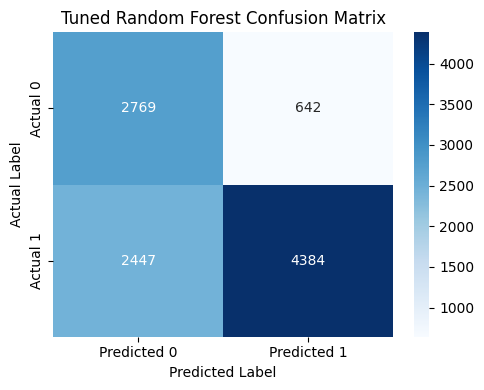

In [24]:
# Confusion matrix for the tuned model
best_cm_behavior = confusion_matrix( y_test_behavior,y_pred_best_behavior)
print(f"tuned model confusion matrix:\n{best_cm_behavior}")

# Plot confusion matrix for the tuned model
plt.figure(figsize=(5, 4))
sns.heatmap(best_cm_behavior,annot=True,fmt="d",cmap="Blues",xticklabels=["Predicted 0", "Predicted 1"],yticklabels=["Actual 0", "Actual 1"])

plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [25]:
# Compare baseline and tuned model accuracy
model_comparison_behavior = pd.DataFrame({
    "model": ["Baseline Random Forest", "Tuned Random Forest"],
    "test_accuracy": [baseline_accuracy_behavior, best_accuracy_behavior]
    })

model_comparison_behavior

,model,test_accuracy
0,Baseline Random Forest,0.689904
1,Tuned Random Forest,0.698399


The tuned Random Forest model reached a test accuracy of about 0.7, which is slightly higher than the baseline accuracy of about 0.690. The bigger improvement is in macro F1-score. The tuned model reached a macro F1-score of about 0.7, compared with the baseline cross-validation macro F1-score of 0.648.

The tuned model uses balanced class weights, which helped the model identify Add to Cart = 0 much better. The recall for class 0 increased to 0.81. However, this also reduced recall for class 1 to 0.64. This shows a tradeoff: the tuned model is better at paying attention to both classes, but it misses more actual add-to-cart cases than the baseline model.

Overall, the tuned model is preferred because it gives a more balanced classification result, not just a high score for the majority class.

#### **1.8 Feature Importance**

Feature importance is reviewed to understand which variables were most useful in the tuned Random Forest model. Random Forest feature importance does not prove causation, but it helps show which features contributed most to the model's predictions.

In [26]:
# Create feature importance dataframe
feature_importance_behavior = pd.DataFrame({"feature": X_train_behavior.columns,"importance": best_rf_behavior.feature_importances_}).sort_values(by="importance", ascending=False).reset_index(drop=True)
feature_importance_behavior.head(15)

,feature,importance
0,Share,0.193871
1,Like,0.140103
2,Browsing Time (min),0.109814
3,Gender_Male,0.081677
4,Age,0.068028
5,Product Category_Fashion,0.029857
6,Product Category_Home & Furniture,0.018159
7,Marital Status_Single,0.014801
8,Segment_Corporate,0.013717
9,Segment_Home Office,0.011227


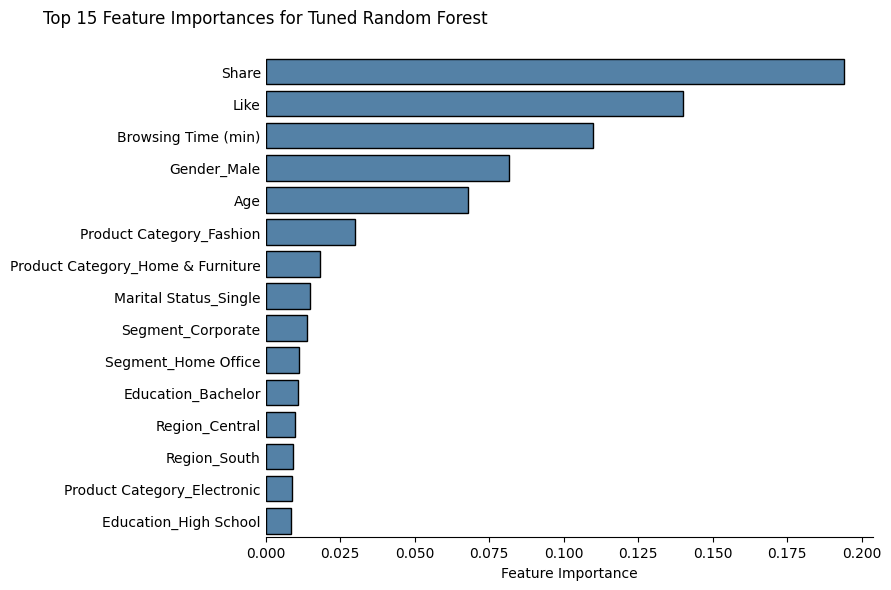

In [27]:
# Plot top 15 feature importances
top_features_behavior = feature_importance_behavior.head(15)

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=top_features_behavior, x="importance", y="feature", color="steelblue",edgecolor="black")

plt.title("Top 15 Feature Importances for Tuned Random Forest", fontsize=12, x=0, y=1.05)
plt.xlabel("Feature Importance")
plt.ylabel(None)
plt.tick_params(axis='y', length=0, labelsize= 10) 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

The most important features in the tuned Random Forest model are Share, Like, and Browsing Time. This suggests that engagement behavior is more useful for predicting Add to Cart than basic customer profile variables. Gender and Age also appear in the top features, but their importance is lower than the engagement variables.

Product category, segment, education, and region have smaller importance values. These variables may still help the model, but they are not the main drivers of prediction. Feature importance does not prove causation; it only shows which variables contributed most to the model's predictions.

#### **1.9 Modeling Conclusion**

The Random Forest model was used to predict Add to Cart behavior for Dataset 1. The baseline model gave a reasonable starting point, but it performed better on the majority class than the minority class. Cross-validation showed that the baseline model was stable, with a mean accuracy of about 0.689 and a mean macro F1-score of about 0.648.

After hyperparameter tuning, the best model used balanced class weights, 300 trees, no maximum depth limit, a minimum of 2 samples per leaf, and a minimum of 2 samples to split a node. The tuned model improved the macro F1-score to about 0.7 and slightly improved test accuracy to about 0.7.

The most useful predictors were Share, Like, and Browsing Time. This supports the idea that customer engagement behavior is important for predicting add-to-cart behavior. The model is not perfect, but it gives a useful supervised learning baseline for understanding purchase-intent behavior in the customer journey.

### **Dataset 2: Sales and Customer Insights**   
This section applies Random Forest modeling to Dataset 2. The dataset was already cleaned in previous steps, so this section starts by loading the cleaned EDA file and checking the basic structure before selecting a target variable.

Unlike Dataset 1, Dataset 2 does not have a ready binary target. The main target-like variables are `Churn_Probability` and `Lifetime_Value`, so the modeling task may be treated as regression unless a binary target is created later.

#### **2.1 Load and Check**

In [28]:
# Load the cleaned dataset from the previous cleaning step
df_sales = pd.read_pickle("data/df_sales_eda.pkl")

# Quick check
df_sales.shape

(10000, 15)

In [29]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Customer_ID               10000 non-null  object        
 1   Product_ID                10000 non-null  object        
 2   Transaction_ID            10000 non-null  object        
 3   Purchase_Frequency        10000 non-null  int64         
 4   Average_Order_Value       10000 non-null  float64       
 5   Most_Frequent_Category    10000 non-null  object        
 6   Time_Between_Purchases    10000 non-null  int64         
 7   Region                    10000 non-null  object        
 8   Churn_Probability         10000 non-null  float64       
 9   Lifetime_Value            10000 non-null  float64       
 10  Launch_Date               10000 non-null  datetime64[ns]
 11  Peak_Sales_Date           10000 non-null  datetime64[ns]
 12  Season             

In [30]:
df_sales.isna().sum()

Customer_ID                 0
Product_ID                  0
Transaction_ID              0
Purchase_Frequency          0
Average_Order_Value         0
Most_Frequent_Category      0
Time_Between_Purchases      0
Region                      0
Churn_Probability           0
Lifetime_Value              0
Launch_Date                 0
Peak_Sales_Date             0
Season                      0
Preferred_Purchase_Times    0
Retention_Strategy          0
dtype: int64

#### **2.2 Target Selection and Target Check**

In [31]:
# Target selection
target_sales = "Churn_Probability"
y_sales = df_sales[target_sales]

y_sales.describe()

count    10000.000000
mean         0.501552
std          0.288289
min          0.000000
25%          0.250000
50%          0.500000
75%          0.750000
max          1.000000
Name: Churn_Probability, dtype: float64

#### **2.3 Feature Selection, Encoding, and Train/Test Split**

For modeling, `Churn_Probability` is used as the target variable. Identifier columns are removed because they do not provide meaningful predictive information and may add noise to the model.

The date columns are converted into simple numeric features before modeling. Categorical variables are encoded using one-hot encoding so they can be used by the Random Forest model.

In [32]:
# Define target
target_sales = "Churn_Probability"

# Remove target, identifiers, and date columns
drop_cols_sales = ["Churn_Probability","Customer_ID","Product_ID","Transaction_ID","Launch_Date","Peak_Sales_Date"]
X_sales = df_sales.drop(columns=drop_cols_sales)
y_sales = df_sales[target_sales]

# Categorical columns to encode
categorical_features_sales = ["Most_Frequent_Category","Region","Season","Preferred_Purchase_Times","Retention_Strategy"]

# One-hot encode categorical variables
X_sales_encoded = pd.get_dummies(X_sales,columns=categorical_features_sales,drop_first=True,dtype=int)

# Train/test split
X_train_sales, X_test_sales, y_train_sales, y_test_sales = train_test_split(X_sales_encoded,y_sales,test_size=0.2,random_state=42)

print("X_train shape:", X_train_sales.shape)
print("X_test shape:", X_test_sales.shape)
print("y_train shape:", y_train_sales.shape)
print("y_test shape:", y_test_sales.shape)

X_train shape: (8000, 17)
X_test shape: (2000, 17)
y_train shape: (8000,)
y_test shape: (2000,)


#### **2.4 Baseline Random Forest Model**

A baseline Random Forest regression model is trained to predict `Churn_Probability`. This baseline model uses default-style settings and gives an initial performance benchmark before cross-validation and hyperparameter tuning.

In [33]:
# Create baseline model
rf_sales_baseline = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)
rf_sales_baseline.fit(X_train_sales, y_train_sales)

# Predict on test set
y_pred_sales_baseline = rf_sales_baseline.predict(X_test_sales)

# Evaluate model
baseline_r2_sales = r2_score(y_test_sales, y_pred_sales_baseline)
baseline_mse_sales = mean_squared_error(y_test_sales, y_pred_sales_baseline)
baseline_rmse_sales = np.sqrt(baseline_mse_sales)
baseline_mae_sales = mean_absolute_error(y_test_sales, y_pred_sales_baseline)

print("Baseline Test R2:", baseline_r2_sales)
print("Baseline Test MSE:", baseline_mse_sales)
print("Baseline Test RMSE:", baseline_rmse_sales)
print("Baseline Test MAE:", baseline_mae_sales)

Baseline Test R2: -0.026237950409428556
Baseline Test MSE: 0.08438793086
Baseline Test RMSE: 0.2904960083374641
Baseline Test MAE: 0.2494394


The baseline Random Forest regression result is consistent with the earlier EDA findings. In previous analysis, the numeric variables showed very weak correlations with `Churn_Probability`, and the scatterplots did not show clear predictive patterns.

The baseline model has a negative test R2 score, which means it does not improve over a simple average-based prediction. This result is not surprising for this dataset because earlier analysis already suggested that the selected features do not explain churn probability well.

The RMSE is about 0.29 and the MAE is about 0.25 on a target that ranges from 0 to 1. Overall, the baseline model confirms that `Churn_Probability` is difficult to predict from the available features in Dataset 2.

#### **2.5 Cross-Validation**

Cross-validation is used to check whether the weak baseline result is consistent across different splits of the data. Since the target is continuous, regular K-fold cross-validation is used instead of stratified cross-validation.

Based on the earlier EDA and the baseline model result, the cross-validation scores are expected to be low or close to zero.

In [34]:
cv_sales = KFold(n_splits=5,shuffle=True,random_state=42)
scoring_sales = {"r2": "r2","mse": "neg_mean_squared_error","mae": "neg_mean_absolute_error"}
cv_results_sales = cross_validate(rf_sales_baseline, X_sales_encoded, y_sales,cv=cv_sales,scoring=scoring_sales,n_jobs=-1)

cv_r2_scores_sales = cv_results_sales["test_r2"]
cv_mse_scores_sales = -cv_results_sales["test_mse"]
cv_mae_scores_sales = -cv_results_sales["test_mae"]

print("CV R2 scores:", cv_r2_scores_sales)
print("Mean CV R2:", cv_r2_scores_sales.mean())
print("Std CV R2:", cv_r2_scores_sales.std())

print("\nMean CV MSE:", cv_mse_scores_sales.mean())
print("Mean CV RMSE:", np.sqrt(cv_mse_scores_sales.mean()))
print("Mean CV MAE:", cv_mae_scores_sales.mean())

CV R2 scores: [-0.03403852 -0.04354642 -0.06129759 -0.04684637 -0.03763838]
Mean CV R2: -0.044673456514722876
Std CV R2: 0.009433426838178058

Mean CV MSE: 0.086788378128
Mean CV RMSE: 0.2945986729909013
Mean CV MAE: 0.25290042


The cross-validation results are consistent with the baseline model and the earlier EDA findings. All five R2 scores are negative, with a mean CV R2 of about -0.045.

This means the model does not predict `Churn_Probability` better than a simple average-based prediction across different data splits. The low standard deviation shows that this weak performance is consistent across folds, not just caused by one unlucky train/test split.

The mean CV RMSE is about 0.295, and the mean CV MAE is about 0.253. Since `Churn_Probability` ranges from 0 to 1, these errors are fairly large.

Overall, cross-validation confirms that the available features do not explain churn probability well in Dataset 2.

#### **2.6 Hyperparameter Tuning**

Hyperparameter tuning is used to check whether changing the Random Forest settings improves prediction performance. Since this is a regression task, the tuning process uses mean squared error as the scoring metric.

Based on the earlier EDA, baseline model, and cross-validation results, large improvement is not expected. The goal is to test whether model tuning can reduce prediction error.

In [35]:
# Hyperparameter tuning for Random Forest Regressor
rf_sales = RandomForestRegressor(random_state=42,n_jobs=-1)

param_grid_sales = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 3],
}

grid_sales = GridSearchCV(estimator=rf_sales,param_grid=param_grid_sales,cv=cv_sales,scoring="neg_mean_squared_error",n_jobs=-1)
grid_sales.fit(X_train_sales, y_train_sales)

print("Best parameters:")
print(grid_sales.best_params_)

print("\nBest CV MSE:")
print(-grid_sales.best_score_)

print("\nBest CV RMSE:")
print(np.sqrt(-grid_sales.best_score_))

Best parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

Best CV MSE:
0.08363340496929299

Best CV RMSE:
0.2891944068776106


The hyperparameter tuning slightly reduced the cross-validation error. The best tuned model used `max_depth = 5`, `min_samples_leaf = 1`, `min_samples_split = 5`, and `n_estimators = 200`.

The best CV RMSE was about 0.289. This is slightly lower than the baseline cross-validation RMSE, which was about 0.295. However, the improvement is small.

This result is consistent with the earlier EDA and baseline modeling results. Tuning can reduce the error slightly, but it does not change the main finding that the available features do not strongly explain `Churn_Probability`.

#### **2.7 Final Tuned Model Evaluation**

The best Random Forest model from hyperparameter tuning is evaluated on the test set. This step checks whether the tuned model improves test performance compared with the baseline model.

In [36]:
# Final tuned model evaluation

best_rf_sales = grid_sales.best_estimator_

# Predict on the test set
y_pred_sales_tuned = best_rf_sales.predict(X_test_sales)

# Evaluate tuned model
tuned_r2_sales = r2_score(y_test_sales, y_pred_sales_tuned)
tuned_mse_sales = mean_squared_error(y_test_sales, y_pred_sales_tuned)
tuned_rmse_sales = np.sqrt(tuned_mse_sales)
tuned_mae_sales = mean_absolute_error(y_test_sales, y_pred_sales_tuned)

print("Tuned Test R2:", tuned_r2_sales)
print("Tuned Test MSE:", tuned_mse_sales)
print("Tuned Test RMSE:", tuned_rmse_sales)
print("Tuned Test MAE:", tuned_mae_sales)

Tuned Test R2: -0.002908796966027971
Tuned Test MSE: 0.08246956583849735
Tuned Test RMSE: 0.28717514836506547
Tuned Test MAE: 0.24795054750420423


#### **2.9 Modeling Conclusion for Dataset 2**

Dataset 2 was modeled using a Random Forest regressor because the target variable, `Churn_Probability`, is continuous.

The earlier EDA already showed weak relationships between the available features and churn probability. The modeling results matched that pattern. The baseline Random Forest model had a negative test R² score, which means it did not perform better than a simple average-based prediction.

Cross-validation confirmed the same result. The R² scores were negative across all folds, showing that the weak performance was consistent and not caused by one specific train/test split.

Hyperparameter tuning slightly reduced the error, but it did not meaningfully improve the model. The tuned model still had a negative test R² score, so it was not useful for predicting churn probability.

Overall, Dataset 2 does not provide a strong supervised learning signal for predicting `Churn_Probability`. The available customer, product, category, region, season, purchase time, and retention strategy features do not explain churn risk well in this dataset. The Random Forest model confirms the earlier EDA finding that Dataset 2 has limited value for meaningful churn prediction.

### **Dataset 3: E-commerce Customer Churn Analysis and Prediction**

#### **3.1 Load and Check**

In [37]:
# Load the cleaned dataset from the previous cleaning step
df_churn = pd.read_pickle("data/df_churn_eda.pkl")

# Quick check
df_churn.shape

(5630, 20)

In [38]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [39]:
df_churn.isna().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

#### **3.2 Target Selection and Target Check**

The target variable for Dataset 3 is `Churn`.

This is a binary classification target because it shows whether a customer churned or did not churn.

Because the target is binary, a `RandomForestClassifier` will be used for this modeling task.

Before modeling, the target distribution is checked to see whether the classes are balanced or imbalanced.

          Count  Percentage
Churn                      
No Churn   4682   83.161634
Churn       948   16.838366


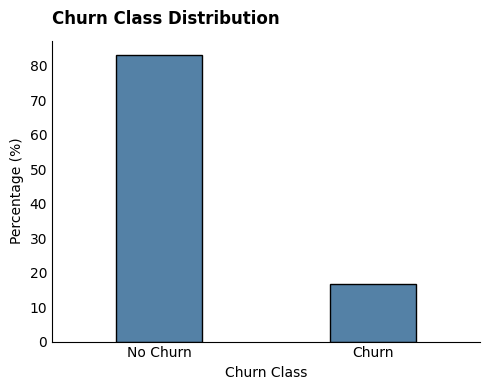

In [40]:
# Target selection and target balance check
target_col_churn = "Churn"

churn_counts = df_churn[target_col_churn].value_counts().sort_index()
churn_percent = df_churn[target_col_churn].value_counts(normalize=True).sort_index() * 100

target_balance_churn = pd.DataFrame({"Count": churn_counts,"Percentage": churn_percent})

target_balance_churn.index = target_balance_churn.index.map({0: "No Churn",1: "Churn"})

print(target_balance_churn)

plt.figure(figsize=(5, 4))

ax = sns.barplot(x=target_balance_churn.index,y=target_balance_churn["Percentage"],color="steelblue",edgecolor="black",width=0.4)

ax.set_title("Churn Class Distribution", loc="left", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Churn Class")
ax.set_ylabel("Percentage (%)")
ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The target variable is `Churn`.

This is a binary classification target because customers are labeled as either churned or not churned.

The class distribution is imbalanced. About 83.2% of customers did not churn, while about 16.8% churned.

Because of this imbalance, model evaluation should not rely only on accuracy. Precision, recall, F1-score, and the confusion matrix will also be important.


#### **3.3 Feature Selection, Encoding, and Train/Test Split**

`Churn` is used as the target variable, and `CustomerID` is removed because it is an identifier.

The EDA version keeps missing values for inspection. For modeling, a model-ready copy is created. Missing-value indicator columns are added first, then the missing numeric values are filled with the median.

Categorical variables are one-hot encoded so they can be used by the Random Forest model.

Because the churn classes are imbalanced, a stratified train/test split is used to keep a similar class distribution in both training and test sets.

In [41]:
df_churn_model = df_churn.copy()

# Columns with missing values
missing_cols = ["DaySinceLastOrder","OrderAmountHikeFromlastYear","Tenure","OrderCount","CouponUsed","HourSpendOnApp","WarehouseToHome"]

# Create missing-value indicators
for col in missing_cols:
    df_churn_model[col + "_was_missing"] = df_churn_model[col].isna().astype(int)

# Median imputation
for col in missing_cols:
    df_churn_model[col] = df_churn_model[col].fillna(df_churn_model[col].median())

# One-hot encode categorical variables
categorical_cols = ["PreferredLoginDevice","PreferredPaymentMode","Gender","PreferedOrderCat","MaritalStatus"]
df_churn_model= pd.get_dummies(df_churn_model,columns=categorical_cols,drop_first=True)

# Define features and target
y_churn = df_churn_model["Churn"]
X_churn = df_churn_model.drop(columns=["Churn", "CustomerID"])

# Split the data into training and test sets
X_train_churn, X_test_churn, y_train_churn, y_test_churn = train_test_split(X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn)

print("Original EDA version shape:", df_churn.shape)
print("Model-ready version shape:", df_churn_model.shape)

print("\nX_train shape:", X_train_churn.shape)
print("X_test shape:", X_test_churn.shape)
print("y_train shape:", y_train_churn.shape)
print("y_test shape:", y_test_churn.shape)

print("\nMissing values after modeling preparation:", df_churn_model.isna().sum().sum())

print("\nTraining target distribution:")
print(y_train_churn.value_counts(normalize=True).sort_index() * 100)

print("\nTest target distribution:")
print(y_test_churn.value_counts(normalize=True).sort_index() * 100)


Original EDA version shape: (5630, 20)
Model-ready version shape: (5630, 34)

X_train shape: (4504, 32)
X_test shape: (1126, 32)
y_train shape: (4504,)
y_test shape: (1126,)

Missing values after modeling preparation: 0

Training target distribution:
Churn
0    83.170515
1    16.829485
Name: proportion, dtype: float64

Test target distribution:
Churn
0    83.12611
1    16.87389
Name: proportion, dtype: float64


#### **3.4 Baseline Random Forest Model**
This baseline model is used before cross-validation and hyperparameter tuning.

Because the target classes are imbalanced, accuracy is reported, but precision, recall, F1-score, and the confusion matrix are also important.

Baseline Test Accuracy: 0.9831261101243339

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.98      1.00      0.99       936
       Churn       0.99      0.91      0.95       190

    accuracy                           0.98      1126
   macro avg       0.99      0.95      0.97      1126
weighted avg       0.98      0.98      0.98      1126



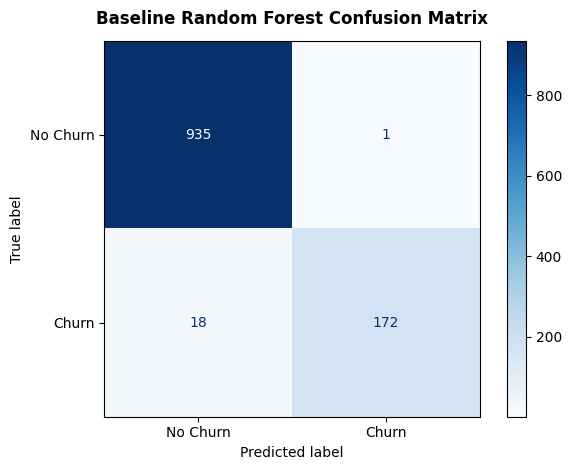

In [42]:
# Baseline Random Forest classifier
rf_baseline_churn = RandomForestClassifier(random_state=42,n_jobs=-1)
rf_baseline_churn.fit(X_train_churn, y_train_churn)

y_pred_baseline_churn = rf_baseline_churn.predict(X_test_churn)
baseline_accuracy_churn = accuracy_score(y_test_churn, y_pred_baseline_churn)

print("Baseline Test Accuracy:", baseline_accuracy_churn)
print("\nClassification Report:")
print(classification_report(y_test_churn, y_pred_baseline_churn, target_names=["No Churn", "Churn"]))
cm_churn = confusion_matrix(y_test_churn, y_pred_baseline_churn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_churn, display_labels=["No Churn", "Churn"])

disp.plot(cmap="Blues")
plt.title("Baseline Random Forest Confusion Matrix", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

The baseline Random Forest classifier performed very strongly on the test set.

The model achieved a test accuracy of about 0.98. It also performed well on both classes, including the smaller `Churn` class.

For the `Churn` class, recall was about 0.91 and F1-score was about 0.95. This means the model correctly identified most churned customers in the test set.

The confusion matrix shows that the model made only a small number of errors. It missed 18 churned customers and incorrectly labeled 1 non-churned customer as churn.

This result is much stronger than expected for many churn problems, so it should be checked with cross-validation before making a final conclusion.



#### **3.5 Cross-Validation**

Cross-validation is used to check whether the baseline Random Forest result is stable across different data splits.

Because this is a classification task with an imbalanced target, `StratifiedKFold` is used.

Both accuracy and macro F1 are reported. Macro F1 is important because it gives more balanced attention to both churn classes.

In [43]:
# Cross-validation for baseline Random Forest classifier
cv_churn = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scoring_churn = {"accuracy": "accuracy","f1_macro": "f1_macro"}
cv_results_churn = cross_validate(rf_baseline_churn,X_churn,y_churn,cv=cv_churn,scoring=scoring_churn,n_jobs=-1)

print("CV Accuracy Scores:", cv_results_churn["test_accuracy"])
print("Mean CV Accuracy:", cv_results_churn["test_accuracy"].mean())
print("Std CV Accuracy:", cv_results_churn["test_accuracy"].std())

print("\nCV Macro F1 Scores:", cv_results_churn["test_f1_macro"])
print("Mean CV Macro F1:", cv_results_churn["test_f1_macro"].mean())
print("Std CV Macro F1:", cv_results_churn["test_f1_macro"].std())

CV Accuracy Scores: [0.97246892 0.95648313 0.95559503 0.97424512 0.97069272]
Mean CV Accuracy: 0.9658969804618117
Std CV Accuracy: 0.008131810403026355

CV Macro F1 Scores: [0.94886699 0.91450597 0.91581938 0.95237908 0.94556809]
Mean CV Macro F1: 0.9354279004603183
Std CV Macro F1: 0.01669129273332656


The cross-validation results show that the baseline Random Forest model is stable across different folds.

The mean cross-validation accuracy is about 0.966, and the mean macro F1 score is about 0.935.

These results are slightly lower than the single test-set result, but they are still strong. This suggests that the model is not only performing well on one train/test split.

The standard deviations are also fairly small, which means the model performance is reasonably consistent across folds.

Overall, cross-validation confirms that the Random Forest classifier has a strong supervised learning signal for predicting churn in Dataset 3.



#### **3.6 Hyperparameter Tuning**

In this step, hyperparameter tuning is used to improve or confirm the Random Forest classifier performance.

Because the baseline and cross-validation results are already strong, tuning is not expected to create a large improvement.

The tuning process uses macro F1 as the scoring metric because the churn classes are imbalanced.

In [44]:
# Hyperparameter tuning for Random Forest classifier
param_grid_churn = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 10, 15, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

grid_search_churn = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_churn,
    scoring="f1_macro",
    cv=cv_churn,
    n_jobs=-1
)

grid_search_churn.fit(X_train_churn, y_train_churn)

print("Best Parameters:")
print(grid_search_churn.best_params_)

print("\nBest CV Macro F1:")
print(grid_search_churn.best_score_)

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Best CV Macro F1:
0.9009829521726846


#### **3.7 Final Tuned Model Evaluation**

In this step, the best tuned Random Forest model is evaluated on the test set.

The tuned model is compared with the baseline model using accuracy, macro F1, the classification report, and the confusion matrix.

This helps show whether hyperparameter tuning improved the final test performance.

Baseline Test Accuracy: 0.9831261101243339
Baseline Test Macro F1: 0.9688000851675715

Tuned Test Accuracy: 0.9813499111900533
Tuned Test Macro F1: 0.9653615097612103

Best GridSearch CV Macro F1:
0.9009829521726846

Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}

Tuned Classification Report:
              precision    recall  f1-score   support

    No Churn       0.98      1.00      0.99       936
       Churn       0.99      0.89      0.94       190

    accuracy                           0.98      1126
   macro avg       0.99      0.95      0.97      1126
weighted avg       0.98      0.98      0.98      1126



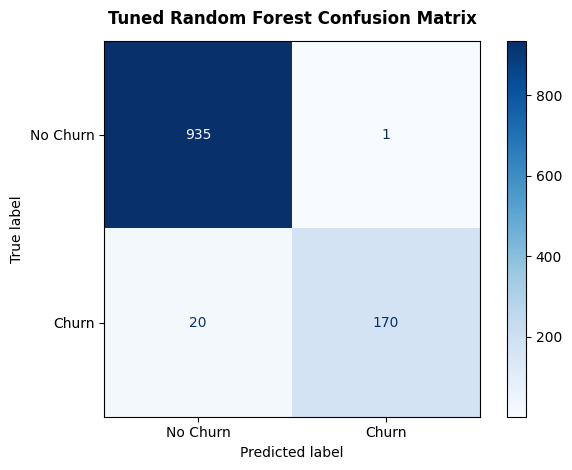

In [45]:
# Final tuned Random Forest model evaluation
best_rf_churn = grid_search_churn.best_estimator_
y_pred_tuned_churn = best_rf_churn.predict(X_test_churn)

tuned_accuracy_churn = accuracy_score(y_test_churn, y_pred_tuned_churn)
tuned_macro_f1_churn = f1_score(y_test_churn, y_pred_tuned_churn, average="macro")

baseline_macro_f1_churn = f1_score(y_test_churn, y_pred_baseline_churn, average="macro")

print("Baseline Test Accuracy:", baseline_accuracy_churn)
print("Baseline Test Macro F1:", baseline_macro_f1_churn)

print("\nTuned Test Accuracy:", tuned_accuracy_churn)
print("Tuned Test Macro F1:", tuned_macro_f1_churn)

print("\nBest GridSearch CV Macro F1:")
print(grid_search_churn.best_score_)

print("\nBest Parameters:")
print(grid_search_churn.best_params_)

print("\nTuned Classification Report:")
print(classification_report(y_test_churn, y_pred_tuned_churn, target_names=["No Churn", "Churn"]))

cm_tuned_churn = confusion_matrix(y_test_churn, y_pred_tuned_churn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned_churn,display_labels=["No Churn", "Churn"])

disp.plot(cmap="Blues")
plt.title("Tuned Random Forest Confusion Matrix", fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

The tuned Random Forest model performed very strongly on the test set, but it did not improve over the baseline model.

The baseline test accuracy was about 0.983, with a macro F1 score of about 0.969.

The tuned model had a test accuracy of about 0.981 and a macro F1 score of about 0.965.

The tuned model correctly predicted most customers in both classes. However, it missed 20 churned customers, while the baseline model missed 18 churned customers.

This means the tuned model was still strong, but the baseline model performed slightly better on the test set.

Overall, hyperparameter tuning did not improve final test performance. The default Random Forest settings already worked very well for this dataset.

#### **3.8 Feature Importance**

Feature importance is used to see which variables the Random Forest model used most when predicting churn.

Since the baseline Random Forest model performed slightly better than the tuned model on the test set, feature importance is calculated from the baseline model.

These importance values show which features were most useful for the model, but they do not prove causation.

,Feature,Importance
0,Tenure,0.200511
12,CashbackAmount,0.094568
2,WarehouseToHome,0.075488
7,Complain,0.063868
6,NumberOfAddress,0.062051
8,OrderAmountHikeFromlastYear,0.059253
11,DaySinceLastOrder,0.057561
5,SatisfactionScore,0.049984
4,NumberOfDeviceRegistered,0.038463
10,OrderCount,0.032374


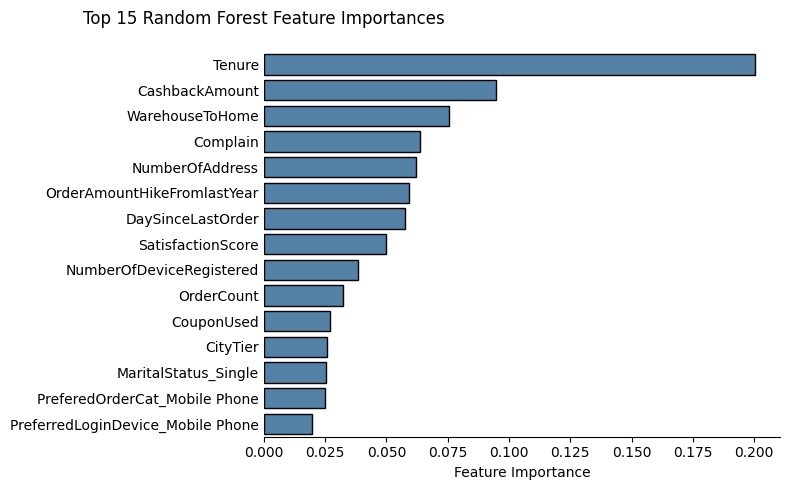

In [46]:
# Feature importance from the baseline Random Forest model

feature_importance_churn = pd.DataFrame({"Feature": X_train_churn.columns,"Importance": rf_baseline_churn.feature_importances_})

feature_importance_churn = feature_importance_churn.sort_values("Importance",ascending=False)

display(feature_importance_churn.head(15))

plt.figure(figsize=(8, 5))

ax = sns.barplot(data=feature_importance_churn.head(15),x="Importance",y="Feature",color="steelblue",edgecolor="black")

ax.set_title("Top 15 Random Forest Feature Importances",  fontsize=12,  x=0, y=1.05)
ax.set_xlabel("Feature Importance")
ax.set_ylabel(None)
ax.tick_params(axis="y", length=0, labelsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

`Tenure` was the most important feature in the baseline Random Forest model.

This matches the earlier EDA because churned customers were more concentrated at lower tenure values.

Other important features included `CashbackAmount`, `WarehouseToHome`, `Complain`, `NumberOfAddress`, and `DaySinceLastOrder`.

Overall, the feature importance results support the earlier EDA findings. Tenure, cashback, delivery distance, complaints, and recent order behavior appear useful for predicting churn.

These results show which features the model used most, but they do not prove causation.


#### **3.9 Modeling Conclusion**

Dataset 3 was modeled using a Random Forest classifier because `Churn` is a binary target variable.

The baseline Random Forest model performed very strongly. It had a test accuracy of about 0.983 and a macro F1 score of about 0.969.

Cross-validation also showed strong and stable performance, with a mean accuracy of about 0.966 and a mean macro F1 score of about 0.935.

Hyperparameter tuning selected a model with 300 trees and a maximum depth of 20. However, the tuned model did not improve test performance. The tuned test accuracy was about 0.981, and the tuned macro F1 score was about 0.965.

Because the baseline model performed slightly better on the test set, the baseline model was used for feature importance.

The most important feature was `Tenure`. Other useful features included `CashbackAmount`, `WarehouseToHome`, `Complain`, `NumberOfAddress`, and `DaySinceLastOrder`.

Overall, the Random Forest model gives a strong supervised learning baseline for predicting customer churn in Dataset 3. The model results also match the earlier EDA findings, especially the importance of tenure and complaint behavior.

These results should still be interpreted carefully because feature importance does not prove causation.



### **Dataset 4: E-Commerce Customer Behavior and Sales Analysis - TR**

#### **4.1 Load and Check**

In [47]:
# Load the cleaned dataset from the previous cleaning step
df_purchase_experience = pd.read_pickle("data/df_purchase_experience_eda.pkl")

# Quick check
df_purchase_experience.shape

(5000, 18)

In [48]:
df_purchase_experience.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order_ID                  5000 non-null   object        
 1   Customer_ID               5000 non-null   object        
 2   Date                      5000 non-null   datetime64[ns]
 3   Age                       5000 non-null   int64         
 4   Gender                    5000 non-null   object        
 5   City                      5000 non-null   object        
 6   Product_Category          5000 non-null   object        
 7   Unit_Price                5000 non-null   float64       
 8   Quantity                  5000 non-null   int64         
 9   Discount_Amount           5000 non-null   float64       
 10  Total_Amount              5000 non-null   float64       
 11  Payment_Method            5000 non-null   object        
 12  Device_Type         

In [49]:
df_purchase_experience.isna().sum() 

Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64

#### **4.2 Target Selection and Target Check**

`High_Value_Order` is created as the target variable.

Orders in the top 25% of `Total_Amount` are labeled as 1. Other orders are labeled as 0.

This is a binary classification task. To avoid an obvious prediction, `Total_Amount`, `Unit_Price`, `Quantity`, and `Discount_Amount` will not be used as predictors.

High-value threshold:
979.6949999999999

Target value counts:


High_Value_Order
0    3750
1    1250
Name: count, dtype: int64


Target class percentage:


High_Value_Order
0    75.0
1    25.0
Name: proportion, dtype: float64

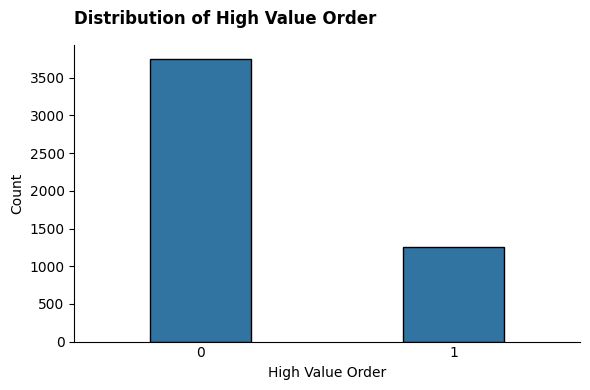

In [50]:
target_purchase = "High_Value_Order"

high_value_threshold_purchase = df_purchase_experience["Total_Amount"].quantile(0.75)

df_purchase_model = df_purchase_experience.copy()

df_purchase_model[target_purchase] = (df_purchase_model["Total_Amount"] >= high_value_threshold_purchase).astype(int)

print("High-value threshold:")
print(high_value_threshold_purchase)

print("\nTarget value counts:")
display(df_purchase_model[target_purchase].value_counts())

print("\nTarget class percentage:")
display(df_purchase_model[target_purchase].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_purchase_model, x=target_purchase, width=0.4, edgecolor="black")
plt.title("Distribution of High Value Order", loc="left", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("High Value Order")
plt.ylabel("Count")
ax.tick_params(axis="x", length=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

The high-value threshold is about 979.69.

The target has 75% non-high-value orders and 25% high-value orders. The classes are not equal, so stratified train/test split is used.

#### **4.3 Feature Selection, Encoding, and Train/Test Split**

Identifier columns, the target source column, and direct price-mechanics columns are removed.

Categorical variables are one-hot encoded. The split uses stratification because the target is imbalanced.

In [51]:
# Date features
df_purchase_model["Order_Month"] = df_purchase_model["Date"].dt.month.astype("category")
df_purchase_model["Order_DayOfWeek"] = df_purchase_model["Date"].dt.dayofweek.astype("category")

# Boolean to integer
df_purchase_model["Is_Returning_Customer"] = df_purchase_model["Is_Returning_Customer"].astype(int)

columns_to_remove_purchase = ["Order_ID","Customer_ID","Date","High_Value_Order","Total_Amount","Unit_Price","Quantity","Discount_Amount","Customer_Rating","Delivery_Time_Days"]

X_purchase = df_purchase_model.drop(columns=columns_to_remove_purchase)
y_purchase = df_purchase_model["High_Value_Order"]

X_purchase_encoded = pd.get_dummies(X_purchase, drop_first=True,dtype=int)

X_train_purchase, X_test_purchase, y_train_purchase, y_test_purchase = train_test_split(
    X_purchase_encoded,
    y_purchase,
    test_size=0.2,
    random_state=42,
    stratify=y_purchase)

print("X_train shape:", X_train_purchase.shape)
print("X_test shape:", X_test_purchase.shape)
print("y_train shape:", y_train_purchase.shape)
print("y_test shape:", y_test_purchase.shape)

print("\nTraining target balance:")
display(y_train_purchase.value_counts(normalize=True) * 100)

print("\nTest target balance:")
display(y_test_purchase.value_counts(normalize=True) * 100)

print("\nEncoded feature columns:")
print(X_purchase_encoded.columns.tolist())

X_train shape: (4000, 45)
X_test shape: (1000, 45)
y_train shape: (4000,)
y_test shape: (1000,)

Training target balance:


High_Value_Order
0    75.0
1    25.0
Name: proportion, dtype: float64


Test target balance:


High_Value_Order
0    75.0
1    25.0
Name: proportion, dtype: float64


Encoded feature columns:
['Age', 'Session_Duration_Minutes', 'Pages_Viewed', 'Is_Returning_Customer', 'Gender_Male', 'Gender_Other', 'City_Ankara', 'City_Antalya', 'City_Bursa', 'City_Eskisehir', 'City_Gaziantep', 'City_Istanbul', 'City_Izmir', 'City_Kayseri', 'City_Konya', 'Product_Category_Books', 'Product_Category_Electronics', 'Product_Category_Fashion', 'Product_Category_Food', 'Product_Category_Home & Garden', 'Product_Category_Sports', 'Product_Category_Toys', 'Payment_Method_Cash on Delivery', 'Payment_Method_Credit Card', 'Payment_Method_Debit Card', 'Payment_Method_Digital Wallet', 'Device_Type_Mobile', 'Device_Type_Tablet', 'Order_Month_2', 'Order_Month_3', 'Order_Month_4', 'Order_Month_5', 'Order_Month_6', 'Order_Month_7', 'Order_Month_8', 'Order_Month_9', 'Order_Month_10', 'Order_Month_11', 'Order_Month_12', 'Order_DayOfWeek_1', 'Order_DayOfWeek_2', 'Order_DayOfWeek_3', 'Order_DayOfWeek_4', 'Order_DayOfWeek_5', 'Order_DayOfWeek_6']


After encoding, the model has 45 predictor columns.

The train and test sets keep the same target balance because stratified split was used.

#### **4.4 Baseline Random Forest Model**

A baseline Random Forest classifier is trained to predict `High_Value_Order`.

Because the target is imbalanced, accuracy and F1 score are both reviewed.

In [52]:
baseline_rf_purchase = RandomForestClassifier(n_estimators=300,random_state=42,class_weight="balanced",n_jobs=-1)

baseline_rf_purchase.fit(X_train_purchase, y_train_purchase)

y_pred_baseline_purchase = baseline_rf_purchase.predict(X_test_purchase)
y_proba_baseline_purchase = baseline_rf_purchase.predict_proba(X_test_purchase)[:, 1]

baseline_results_purchase = pd.DataFrame({
    "Model": ["Baseline Random Forest"],
    "Accuracy": [accuracy_score(y_test_purchase, y_pred_baseline_purchase)],
    "Precision": [precision_score(y_test_purchase, y_pred_baseline_purchase)],
    "Recall": [recall_score(y_test_purchase, y_pred_baseline_purchase)],
    "F1": [f1_score(y_test_purchase, y_pred_baseline_purchase)],
    "ROC_AUC": [roc_auc_score(y_test_purchase, y_proba_baseline_purchase)]
})

display(baseline_results_purchase)

print("Confusion Matrix:")
print(confusion_matrix(y_test_purchase, y_pred_baseline_purchase))

print("\nClassification Report:")
print(classification_report(y_test_purchase, y_pred_baseline_purchase))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Baseline Random Forest,0.838,0.72,0.576,0.64,0.891488


Confusion Matrix:
[[694  56]
 [106 144]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.93      0.90       750
           1       0.72      0.58      0.64       250

    accuracy                           0.84      1000
   macro avg       0.79      0.75      0.77      1000
weighted avg       0.83      0.84      0.83      1000



The baseline Random Forest model performs reasonably well.

Accuracy is 0.84 and ROC-AUC is 0.89. The model predicts non-high-value orders better than high-value orders.

For high-value orders, recall is 0.58 and F1 is 0.64. This means the model finds many high-value orders, but still misses some of them.

#### **4.5 Cross-Validation**

Stratified cross-validation is used to check whether the model performance is stable across different folds.

In [53]:
cv_purchase = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

cv_scoring_purchase = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results_purchase = cross_validate(
    baseline_rf_purchase,
    X_purchase_encoded,
    y_purchase,
    cv=cv_purchase,
    scoring=cv_scoring_purchase,
    n_jobs=-1
)

cv_summary_purchase = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"],
    "Mean": [
        cv_results_purchase["test_accuracy"].mean(),
        cv_results_purchase["test_precision"].mean(),
        cv_results_purchase["test_recall"].mean(),
        cv_results_purchase["test_f1"].mean(),
        cv_results_purchase["test_roc_auc"].mean()],
    "Standard Deviation": [
        cv_results_purchase["test_accuracy"].std(),
        cv_results_purchase["test_precision"].std(),
        cv_results_purchase["test_recall"].std(),
        cv_results_purchase["test_f1"].std(),
        cv_results_purchase["test_roc_auc"].std()]
})

cv_summary_purchase

,Metric,Mean,Standard Deviation
0,Accuracy,0.829200,0.010998
1,Precision,0.727591,0.034689
2,Recall,0.508000,0.029611
3,F1,0.597724,0.026557
4,ROC_AUC,0.882413,0.008498


Cross-validation results are close to the test-set results.

The mean accuracy is about 0.83, mean F1 is about 0.60, and mean ROC-AUC is about 0.88. The low standard deviations suggest that the model performance is fairly stable.

#### **4.6 Hyperparameter Tuning**

GridSearchCV is used to tune the Random Forest model.

F1 score is used for tuning because the high-value class is smaller than the non-high-value class.

In [54]:
rf_tuning_purchase = RandomForestClassifier(random_state=42,n_jobs=-1)

param_grid_purchase = {
    "n_estimators": [200, 300, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf":  [2],
    "class_weight": ["balanced", "balanced_subsample"]
}

grid_search_purchase = GridSearchCV(estimator=rf_tuning_purchase,param_grid=param_grid_purchase,cv=cv_purchase,scoring="f1",n_jobs=-1)

grid_search_purchase.fit(X_train_purchase, y_train_purchase)

print("Best parameters:")
print(grid_search_purchase.best_params_)

print("\nBest CV F1:")
print(grid_search_purchase.best_score_)

Best parameters:
{'class_weight': 'balanced_subsample', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}

Best CV F1:
0.6769816241985467


GridSearchCV selected the best Random Forest settings.

The best model used 400 trees, `max_depth=10`, and `class_weight="balanced_subsample"`.

The best cross-validation F1 score is about 0.68, which is better than the baseline F1 score.

#### **4.7 Final Tuned Model Evaluation**

The tuned Random Forest model is evaluated on the test set.

In [55]:
best_rf_purchase = grid_search_purchase.best_estimator_

y_pred_tuned_purchase = best_rf_purchase.predict(X_test_purchase)
y_proba_tuned_purchase = best_rf_purchase.predict_proba(X_test_purchase)[:, 1]

tuned_results_purchase = pd.DataFrame({
    "Model": ["Tuned Random Forest"],
    "Accuracy": [accuracy_score(y_test_purchase, y_pred_tuned_purchase)],
    "Precision": [precision_score(y_test_purchase, y_pred_tuned_purchase)],
    "Recall": [recall_score(y_test_purchase, y_pred_tuned_purchase)],
    "F1": [f1_score(y_test_purchase, y_pred_tuned_purchase)],
    "ROC_AUC": [roc_auc_score(y_test_purchase, y_proba_tuned_purchase)]
})

display(tuned_results_purchase)

print("Confusion Matrix:")
print(confusion_matrix(y_test_purchase, y_pred_tuned_purchase))

print("\nClassification Report:")
print(classification_report(y_test_purchase, y_pred_tuned_purchase))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Tuned Random Forest,0.806,0.577348,0.836,0.683007,0.88656


Confusion Matrix:
[[597 153]
 [ 41 209]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.80      0.86       750
           1       0.58      0.84      0.68       250

    accuracy                           0.81      1000
   macro avg       0.76      0.82      0.77      1000
weighted avg       0.85      0.81      0.82      1000



The tuned model improves F1 for the high-value class.

Accuracy is lower than the baseline model, but recall for high-value orders increases from 0.58 to 0.84. This means the tuned model finds more high-value orders, but it also creates more false positives.

Since the goal is to identify high-value orders, the tuned model is more useful.

#### **4.8 Feature Importance**

Feature importance is used to see which predictors the tuned model used most.

,Feature,Importance
16,Product_Category_Electronics,0.307546
18,Product_Category_Food,0.113381
15,Product_Category_Books,0.109215
19,Product_Category_Home & Garden,0.101939
20,Product_Category_Sports,0.053862
21,Product_Category_Toys,0.049284
0,Age,0.037039
1,Session_Duration_Minutes,0.033979
2,Pages_Viewed,0.027875
17,Product_Category_Fashion,0.016675


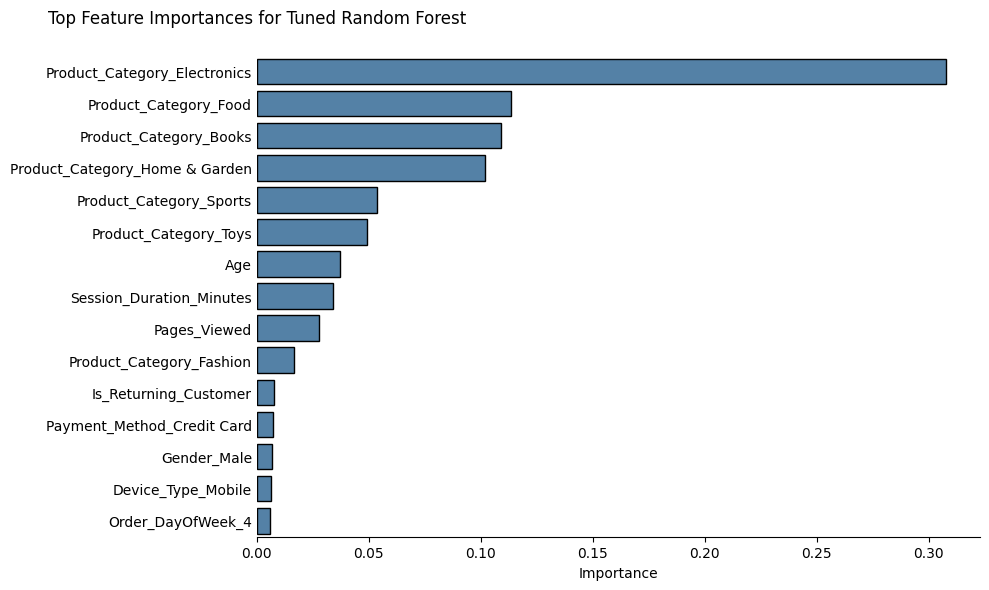

In [56]:
feature_importance_purchase = pd.DataFrame({
    "Feature": X_train_purchase.columns,
    "Importance": best_rf_purchase.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance_purchase.head(15))

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=feature_importance_purchase.head(15),x="Importance",y="Feature",color="steelblue",edgecolor="black")

ax.set_title("Top Feature Importances for Tuned Random Forest",  fontsize=12,  x=0, y=1.05)
ax.set_xlabel("Importance")
ax.set_ylabel(None)
ax.tick_params(axis="y", length=0, labelsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

Product category is the most important predictor in the tuned model.

`Product_Category_Electronics` has the highest importance. This suggests that product type is the strongest signal for identifying high-value orders after direct price variables are removed.

Feature importance does not prove causation. It only shows which features the model used most.

#### **4.8 Feature Importance**

Feature importance is used to see which predictors the tuned model used most.

#### **4.9 Modeling Conclusion**

The final target is `High_Value_Order`, a binary target based on the top 25% of `Total_Amount`.

Direct price-mechanics columns were removed to avoid an obvious prediction. The final tuned Random Forest model achieved accuracy of 0.81, F1 of 0.68, and ROC-AUC of 0.89.

The tuned model improved recall for high-value orders, but it also produced more false positives. Product category was the strongest predictor, especially Electronics.

Overall, Dataset 4 provides a useful classification model for identifying high-value orders.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in chapter seven (p. 165-185) of the Storytelling With Data book as best you can. You do not have to get the exact data values right, just the overall look and feel.

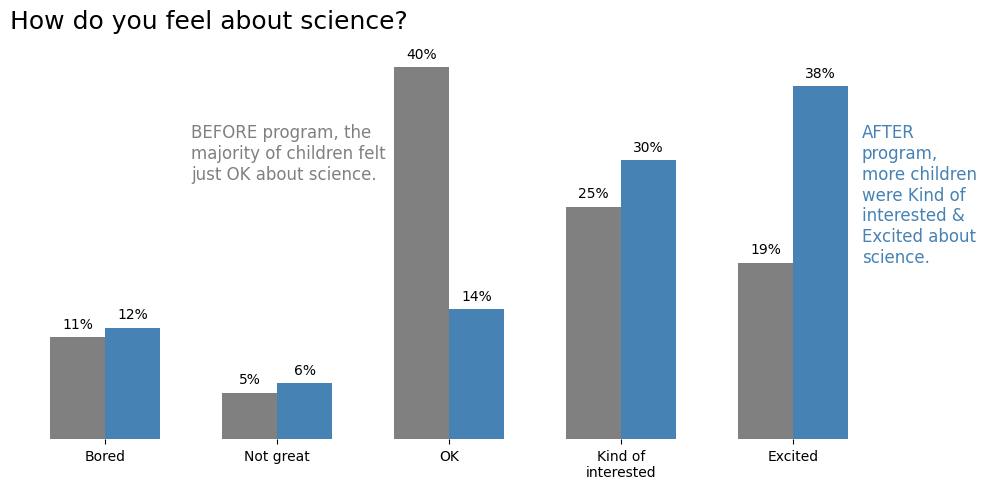

In [57]:
categories = ["Bored", "Not great", "OK", "Kind of\ninterested", "Excited"]
before = [11, 5, 40, 25, 19]
after = [12, 6, 14, 30, 38]
x = np.arange(len(categories))
width = 0.32

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, before, width, color="gray", label="Before")
plt.bar(x + width/2, after, width, color="steelblue", label="After")

# customize the axes and title
plt.xticks(x, categories)
plt.yticks([])
plt.title("How do you feel about science?", loc="left", fontsize=18, pad=15)

# add percentage labels on top of the bars
for i in range(len(categories)):
    plt.text(x[i] - width/2, before[i] + 1, f"{before[i]}%", ha="center", fontsize=10)
    plt.text(x[i] + width/2, after[i] + 1, f"{after[i]}%", ha="center", fontsize=10)

# add annotations to explain the changes
plt.text(4.4, 34,"AFTER\nprogram,\nmore children\nwere Kind of\ninterested &\nExcited about\nscience.",
         color="steelblue",fontsize=12,va="top")

plt.text(0.5, 34,"BEFORE program, the \nmajority of children felt\njust OK about science.",
         color="gray", fontsize=12,va="top")

# remove axes spines for a cleaner look
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.show()